In [1]:
!pip install kaggle --quiet

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tanishk4567890","key":"6fca5bb6370238cabdd9ff3328327aa9"}'}

In [3]:
!mkdir ~/.kaggle

In [4]:
!cp kaggle.json ~/.kaggle/

In [5]:
ls -ltr ~/.kaggle/

total 4
-rw-r--r-- 1 root root 70 May 26 05:46 kaggle.json


In [6]:
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets list -s 'UTK Face'

ref                                                      title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
abhikjha/utk-face-cropped                                UTK Face Cropped                                    243584746  2019-05-03 18:35:14.043000           5158         46  0.5625           
ayushkumar0801/utk-face-extracted-info                   UTK Face Extracted Info                                408873  2021-06-02 13:10:48.570000            187          3  0.9705882        
moritzm00/utkface-cropped                                UTKFace (Aligned & Cropped)                         121383491  2023-04-16 11:40:42.277000           3446         11  0.75             
alifshahariar/utkface-dataset-face-align

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Conv2D, Dense, MaxPooling2D

In [ ]:
train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/Dataset/mnist/MNIST Dataset JPG format/MNIST - JPG - training',
    labels='inferred',
    label_mode='int',
    batch_size=100,
    image_size=(28,28),
    color_mode='grayscale'
)

valid_ds=keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/Dataset/mnist/MNIST Dataset JPG format/MNIST - JPG - testing',
    labels='inferred',
    label_mode='int',
    batch_size=100,
    image_size=(28,28),
    color_mode='grayscale'
)

Found 59026 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


In [ ]:
def process(image, label):
  image=tf.cast(image/255. , tf.float32)
  return image, label

train_ds=train_ds.map(process)
valid_ds=valid_ds.map(process)

In [ ]:
model=Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,090 (461.29 KB)

 Trainable params: 118,090 (461.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
log=model.fit(train_ds, epochs=10, validation_data=valid_ds)

Epoch 1/10
 72/591 ━━━━━━━━━━━━━━━━━━━━ 3:49:15 27s/step - accuracy: 0.5017 - loss: 1.6558

# **ways to reduce overfitting**

Data Augmentation

add more data

dropout

batch normalization

L1,L2 regularizers

Reduce complexity of CNN Model


In [ ]:
import matplotlib.pyplot as plt
import cv2

In [ ]:
test_img=cv2.imread('/content/247.jpg')

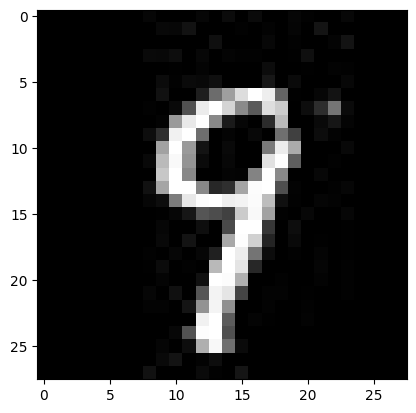

In [ ]:
plt.imshow(test_img)

In [ ]:
test_img.shape

(28, 28, 3)

In [ ]:
# DO if needed resizing of test input
test_img=cv2.resize(test_img,(28,28))

In [ ]:
test_ip=test_img.reshape(1,28,28,3)

In [ ]:
model.predict(test_ip)